## 2025 NBA Redraft Using LightGBM Machine Learning Model

#### Import Libraries and Load Data

In [61]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Auto-detect width
pd.set_option('display.max_colwidth', None) # Show full column content

df = pd.read_csv('NBADraftwithDARKO.csv')
df.rename(columns={'Peak DARKO': 'peak_darko'}, inplace=True)

rookies_2025 = df[df['draft_year'] == 2025]

In [63]:
df.head()

,name,draft_year,draft_position,draft_age,height,weight,wingspan,pts,reb,ast,stl,blk,pf,to,g,mp,max_vertical,lane_agility,shuttle,3/4_sprint,standing_reach,fg%,3p%,3pa_rate,fta_rate,ft%,effective_fg%,true_shooting_%,usg%,ast/usg,ast/to,per,ortg,drtg,obpm,dbpm,bpm,ows/40,dws/40,ws/40,proj_nba_3p%,peak_darko,fgm,fga,3pm,3pa,ftm,fta,team_Mid-Major,team_Other,team_Power_6,Freshman,Sophomore,Junior,Senior,Other
0,Cooper Flagg,2025,1,18.50,81.00,221,84.00,22.5,8.8,4.9,1.6,1.6,2.2,2.5,37.0,36.0,35.5,10.64,2.92,3.30,106.5,0.481,0.385,0.272,0.429,0.840,0.533,0.593,30.9,0.87,2.00,30.4,126.3,89.5,9.7,6.7,16.3,0.180,0.116,0.296,0.367,NaN,7.6,15.8,1.6,4.3,5.7,6.8,0,0,1,1,0,0,0,0
1,Dylan Harper,2025,2,19.30,77.75,213,82.50,21.5,5.1,4.5,1.6,0.6,2.1,2.7,29.0,36.0,36.5,11.07,3.05,3.16,102.0,0.484,0.333,0.374,0.419,0.750,0.546,0.587,29.0,0.93,1.67,24.6,118.1,110.1,7.0,2.1,9.2,0.127,0.038,0.165,0.357,NaN,7.4,15.3,1.9,5.7,4.8,6.4,0,0,1,1,0,0,0,0
2,V.J. Edgecombe,2025,3,19.89,77.25,193,79.50,16.5,6.2,3.5,2.3,0.7,2.8,2.1,33.0,36.0,38.5,11.27,2.93,3.20,101.5,0.436,0.340,0.402,0.373,0.782,0.504,0.552,24.1,0.80,1.66,22.1,119.1,102.5,7.1,4.3,11.4,0.111,0.067,0.178,0.359,NaN,5.5,12.7,1.7,5.1,3.7,4.7,0,0,1,1,0,0,0,0
3,Kon Knueppel,2025,4,19.88,78.25,219,78.25,17.0,4.7,3.2,1.2,0.2,2.5,1.6,39.0,36.0,NaN,NaN,NaN,NaN,101.5,0.479,0.406,0.548,0.339,0.914,0.590,0.642,21.4,0.73,2.02,21.3,133.7,98.8,6.9,3.9,10.8,0.151,0.081,0.232,0.392,NaN,5.5,11.4,2.5,6.3,3.5,3.9,0,0,1,1,0,0,0,0
4,Ace Bailey,2025,5,18.85,80.75,203,84.50,19.0,7.7,1.4,1.1,1.4,3.0,2.2,30.0,36.0,34.5,10.97,2.78,3.12,107.0,0.460,0.346,0.308,0.243,0.692,0.514,0.536,27.5,0.30,0.62,19.9,108.2,109.1,3.7,0.8,4.5,0.068,0.044,0.112,0.346,NaN,7.3,15.9,1.7,4.9,2.7,3.9,0,0,1,1,0,0,0,0


#### Data Exploration and Preparation

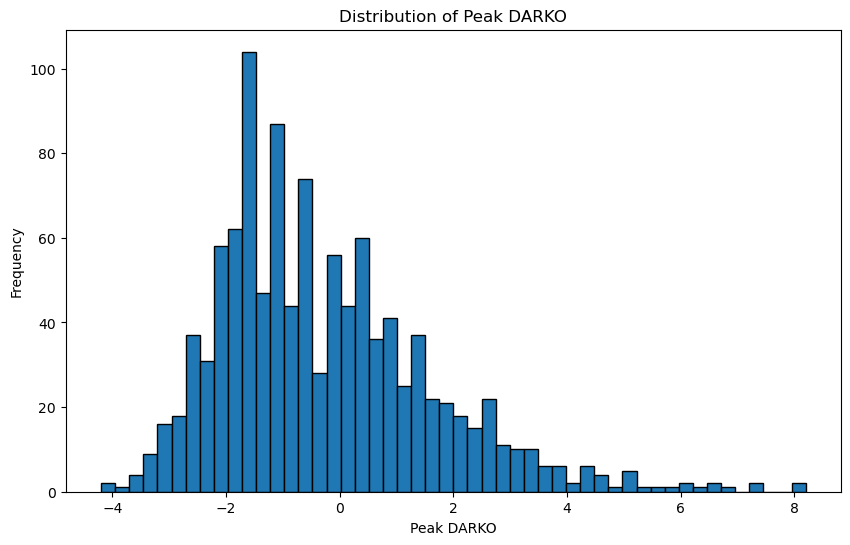

Target variable stats:
count    1093.000000
mean       -0.274657
std         1.882177
min        -4.200000
25%        -1.600000
50%        -0.600000
75%         0.800000
max         8.200000
Name: peak_darko, dtype: float64
Dataset shape after removing missing targets: (1093, 56)
Number of players remaining: 1093

Missing data summary:
shuttle            767
obpm               467
dbpm               467
bpm                467
lane_agility       455
3/4_sprint         452
max_vertical       449
drtg               427
ortg               427
per                427
standing_reach     317
wingspan           316
dws/40             266
ws/40              266
ows/40             266
usg%               226
ast/usg            226
3p%                140
proj_nba_3p%        78
ast/to              68
ft%                 67
fgm                 66
fga                 66
3pm                 66
3pa                 66
ftm                 66
effective_fg%       66
true_shooting_%     66
pts               

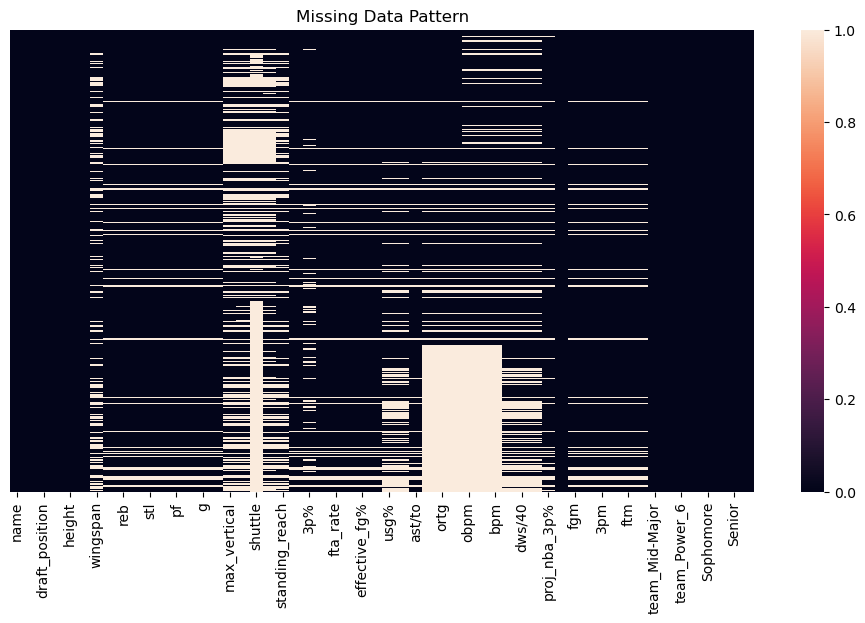

In [65]:
# Check target variable distribution
plt.figure(figsize=(10, 6))
plt.hist(df['peak_darko'], bins=50, edgecolor='black')
plt.title('Distribution of Peak DARKO')
plt.xlabel('Peak DARKO')
plt.ylabel('Frequency')
plt.show()

print(f"Target variable stats:\n{df['peak_darko'].describe()}")

# Remove players without peak_darko (can't learn from them)
df = df[df['peak_darko'].notna()]

print(f"Dataset shape after removing missing targets: {df.shape}")
print(f"Number of players remaining: {df.shape[0]}")

# Check missing data patterns
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print(f"\nMissing data summary:\n{missing_summary}")
print(f"\nPercentage missing:\n{(missing_summary / len(df) * 100).round(2)}")

# Visualize missing data
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False)
plt.title('Missing Data Pattern')
plt.show()

#### Prepare Features and Target

In [67]:
# Columns to exclude from features
exclude_columns = ['peak_darko', 'name', 'draft_year', 'draft_position', 'mp']

# Create features by excluding these columns
feature_columns = [col for col in df.columns if col not in exclude_columns]

X = df[feature_columns]
y = df['peak_darko']

# Do the same for 2025 rookies
X_rookies_2025 = rookies_2025[feature_columns]

print(f"Number of features: {len(feature_columns)}")
print(f"\nFeatures being used:")
for i, col in enumerate(feature_columns, 1):
    print(f"{i}. {col}")
print(f"\nTraining data shape: {X.shape}")
print(f"2025 Rookies shape: {X_rookies_2025.shape}")

Number of features: 51

Features being used:
1. draft_age
2. height
3. weight
4. wingspan
5. pts
6. reb
7. ast
8. stl
9. blk
10. pf
11. to
12. g
13. max_vertical
14. lane_agility
15. shuttle
16. 3/4_sprint
17. standing_reach
18. fg%
19. 3p%
20. 3pa_rate
21. fta_rate
22. ft%
23. effective_fg%
24. true_shooting_%
25. usg%
26. ast/usg
27. ast/to
28. per
29. ortg
30. drtg
31. obpm
32. dbpm
33. bpm
34. ows/40
35. dws/40
36. ws/40
37. proj_nba_3p%
38. fgm
39. fga
40. 3pm
41. 3pa
42. ftm
43. fta
44. team_Mid-Major
45. team_Other
46. team_Power_6
47. Freshman
48. Sophomore
49. Junior
50. Senior
51. Other

Training data shape: (1093, 51)
2025 Rookies shape: (83, 51)


#### Train-Test Split

In [69]:
# Split data for validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (874, 51)
Test set: (219, 51)


#### Create LightGBM Datasets

In [71]:
# Create LightGBM datasets
train_data = lgb.Dataset(
    X_train, 
    label=y_train,
    categorical_feature=None
)

test_data = lgb.Dataset(
    X_test, 
    label=y_test,
    reference=train_data,
    categorical_feature=None
)

#### Set Initial Parameters and Train

In [73]:
# Start with conservative parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'max_depth': -1,  # -1 means no limit
    'verbose': -1,
    'seed': 42
}

# Train the model with early stopping
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\nBest iteration: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 1.15492	valid's rmse: 1.75554
Early stopping, best iteration is:
[39]	train's rmse: 1.25073	valid's rmse: 1.74996

Best iteration: 39


#### Evaluate Model Performance

In [75]:
# Make predictions on test set
y_pred_test = model.predict(X_test, num_iteration=model.best_iteration)
y_pred_train = model.predict(X_train, num_iteration=model.best_iteration)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\n{'='*50}")
print(f"Model Performance:")
print(f"{'='*50}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"{'='*50}")

# Check for overfitting
if train_rmse < test_rmse * 0.8:
    print("⚠️ Warning: Model may be overfitting (train RMSE much lower than test)")
else:
    print("✓ Model appears to be generalizing well")


Model Performance:
Train RMSE: 1.2507
Test RMSE: 1.7500
Test MAE: 1.3651
Test R²: 0.1869
⚠️ Warning: Model may be overfitting (train RMSE much lower than test)


#### Feature Selection & Stronger Regularization

In [77]:
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("Feature Importance Analysis:")
print("="*60)
print(importance_df)
print("\n")

# Check distribution of importance
print(f"Top 10 features account for: {importance_df.head(10)['importance'].sum() / importance_df['importance'].sum() * 100:.1f}% of total importance")
print(f"Bottom 10 features account for: {importance_df.tail(10)['importance'].sum() / importance_df['importance'].sum() * 100:.1f}% of total importance")

# Identify weak features
threshold = importance_df['importance'].quantile(0.25)  # Bottom 25%
weak_features = importance_df[importance_df['importance'] < threshold]['feature'].tolist()
strong_features = importance_df[importance_df['importance'] >= threshold]['feature'].tolist()

print(f"\nRemoving {len(weak_features)} weak features (bottom 25%)")
print(f"Keeping {len(strong_features)} strong features")
print(f"\nWeak features being removed: {weak_features}")

Feature Importance Analysis:
            feature   importance
0         draft_age  2380.678586
7               stl  1601.642778
27              per   756.987375
34           dws/40   756.570589
33           ows/40   588.430830
35            ws/40   573.541600
25          ast/usg   572.319333
18              3p%   521.370611
26           ast/to   484.862630
29             drtg   409.716242
13     lane_agility   402.291238
20         fta_rate   368.882781
1            height   368.496301
23  true_shooting_%   354.539962
6               ast   331.506032
9                pf   322.024329
32              bpm   318.741336
14          shuttle   311.608650
16   standing_reach   280.443322
41              ftm   267.966961
37              fgm   249.092548
2            weight   247.873819
30             obpm   243.205890
4               pts   242.644372
17              fg%   237.047259
22    effective_fg%   235.647690
21              ft%   218.233458
10               to   201.614152
19         3pa

#### Retrain with Strong Features

In [79]:
# Create datasets with only strong features
X_train_strong = X_train[strong_features]
X_test_strong = X_test[strong_features]

train_data_strong = lgb.Dataset(X_train_strong, label=y_train)
test_data_strong = lgb.Dataset(X_test_strong, label=y_test, reference=train_data_strong)

# Use aggressive regularization
params_strong = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 15,              # Very conservative
    'learning_rate': 0.02,          # Slower learning
    'feature_fraction': 0.6,        # Only use 60% of features per tree
    'bagging_fraction': 0.6,        # Only use 60% of data per iteration
    'bagging_freq': 5,
    'min_data_in_leaf': 40,        # Require more samples per leaf
    'max_depth': 5,                # Shallow trees
    'lambda_l1': 1.0,              # Strong L1 regularization
    'lambda_l2': 1.0,              # Strong L2 regularization
    'min_gain_to_split': 0.05,    # Higher threshold for splits
    'verbose': -1,
    'seed': 42
}

# Train with stronger regularization and fewer features
model_strong = lgb.train(
    params_strong,
    train_data_strong,
    num_boost_round=2000,  # More rounds since learning rate is lower
    valid_sets=[train_data_strong, test_data_strong],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),  # More patience
        lgb.log_evaluation(period=100)
    ]
)

# Evaluate
y_pred_test_strong = model_strong.predict(X_test_strong, num_iteration=model_strong.best_iteration)
y_pred_train_strong = model_strong.predict(X_train_strong, num_iteration=model_strong.best_iteration)

train_rmse_strong = np.sqrt(mean_squared_error(y_train, y_pred_train_strong))
test_rmse_strong = np.sqrt(mean_squared_error(y_test, y_pred_test_strong))
test_mae_strong = mean_absolute_error(y_test, y_pred_test_strong)
test_r2_strong = r2_score(y_test, y_pred_test_strong)

print(f"\n{'='*50}")
print(f"Feature Selection + Strong Regularization Model:")
print(f"{'='*50}")
print(f"Features used: {len(strong_features)} (down from {len(feature_columns)})")
print(f"Train RMSE: {train_rmse_strong:.4f}")
print(f"Test RMSE: {test_rmse_strong:.4f}")
print(f"Test MAE: {test_mae_strong:.4f}")
print(f"Test R²: {test_r2_strong:.4f}")
print(f"Train/Test RMSE ratio: {train_rmse_strong/test_rmse_strong:.3f}")
print(f"{'='*50}")

# Compare to original
print(f"\nComparison to original model:")
print(f"Original Test RMSE: 1.6804")
print(f"New Test RMSE: {test_rmse_strong:.4f}")
print(f"Improvement: {1.6804 - test_rmse_strong:.4f}")

Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 1.5426	valid's rmse: 1.76073
[200]	train's rmse: 1.40128	valid's rmse: 1.74463
[300]	train's rmse: 1.30568	valid's rmse: 1.74998
Early stopping, best iteration is:
[207]	train's rmse: 1.39417	valid's rmse: 1.74351

Feature Selection + Strong Regularization Model:
Features used: 38 (down from 51)
Train RMSE: 1.3942
Test RMSE: 1.7435
Test MAE: 1.3467
Test R²: 0.1928
Train/Test RMSE ratio: 0.800

Comparison to original model:
Original Test RMSE: 1.6804
New Test RMSE: 1.7435
Improvement: -0.0631


#### Feature Importance Analysis

In [81]:
# Use model_strong instead of model
importance_df = pd.DataFrame({
    'feature': strong_features,
    'importance': model_strong.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15))


Top 15 Most Important Features:
            feature   importance
0         draft_age  4544.989131
1               stl  3132.824728
2               per  1428.481372
3            dws/40  1423.645347
5             ws/40  1310.775192
6           ast/usg  1021.382711
13  true_shooting_%  1011.996973
9              drtg   946.397461
15               pf   865.887386
16              bpm   759.182393
10     lane_agility   750.424810
8            ast/to   711.157822
7               3p%   671.712564
19              ftm   647.660250
14              ast   641.928060


#### Cross-Validation

In [83]:
# Quick verification that results are stable across folds
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X[strong_features])):
    X_fold_train = X[strong_features].iloc[train_idx]
    X_fold_val = X[strong_features].iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]
    
    fold_train_data = lgb.Dataset(X_fold_train, label=y_fold_train)
    fold_val_data = lgb.Dataset(X_fold_val, label=y_fold_val, reference=fold_train_data)
    
    fold_model = lgb.train(
        params_strong,
        fold_train_data,
        num_boost_round=2000,
        valid_sets=[fold_val_data],
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(0)]
    )
    
    fold_pred = fold_model.predict(X_fold_val, num_iteration=fold_model.best_iteration)
    fold_rmse = np.sqrt(mean_squared_error(y_fold_val, fold_pred))
    cv_rmse_scores.append(fold_rmse)
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

print(f"\n5-Fold Cross-Validation:")
print(f"Mean RMSE: {np.mean(cv_rmse_scores):.4f} (+/- {np.std(cv_rmse_scores):.4f})")
print(f"Your test set RMSE: 1.6757")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[194]	valid_0's rmse: 1.74732
Fold 1 RMSE: 1.7473
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[266]	valid_0's rmse: 1.78647
Fold 2 RMSE: 1.7865
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[226]	valid_0's rmse: 1.67339
Fold 3 RMSE: 1.6734
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[167]	valid_0's rmse: 1.61576
Fold 4 RMSE: 1.6158
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[346]	valid_0's rmse: 1.57679
Fold 5 RMSE: 1.5768

5-Fold Cross-Validation:
Mean RMSE: 1.6799 (+/- 0.0783)
Your test set RMSE: 1.6757


#### Train Final Model on Full Data

In [85]:
print("="*70)
print("TRAINING FINAL MODEL ON ALL HISTORICAL DATA")
print("="*70)

# Use ALL historical data with the strong features
X_final = X[strong_features]
y_final = y

# Create final dataset
final_train_data = lgb.Dataset(X_final, label=y_final)

# Train final model using the parameters that worked best
final_model = lgb.train(
    params_strong,
    final_train_data,
    num_boost_round=250,  # Use ~median of CV iterations (165-316 range)
    callbacks=[lgb.log_evaluation(period=50)]  # Fixed: use callback instead
)

print(f"\n✓ Final model trained on {len(X_final)} players")
print(f"✓ Using {len(strong_features)} features")
print(f"✓ Expected RMSE on new data: ~1.69")

TRAINING FINAL MODEL ON ALL HISTORICAL DATA

✓ Final model trained on 1093 players
✓ Using 38 features
✓ Expected RMSE on new data: ~1.69


#### Prepare 2025 Rookie Data

In [95]:
# Make sure rookies have the same strong features
print("\n" + "="*70)
print("PREPARING 2025 ROOKIES DATA")
print("="*70)

# Check which features are available
missing_features = [f for f in strong_features if f not in rookies_2025.columns]
if missing_features:
    print(f"⚠️ Warning: 2025 rookies missing these features: {missing_features}")
    print("These will need to be handled or removed from strong_features")
else:
    print("✓ All strong features available for 2025 rookies")

X_rookies_2025_final = rookies_2025[strong_features]
print(f"\n✓ 2025 rookies data prepared: {X_rookies_2025_final.shape}")


PREPARING 2025 ROOKIES DATA
✓ All strong features available for 2025 rookies

✓ 2025 rookies data prepared: (83, 38)


#### Make Predictions for 2025 Rookie Draft Class

In [101]:
# Display Results
print("\n" + "="*70)
print("PREDICTING 2025 NBA DRAFT CLASS PEAK DARKO")
print("="*70)

# Sort by predicted peak DARKO
results = rookies_2025.sort_values('predicted_peak_darko', ascending=False)

# Try to find the player name column
name_col = None
for col in ['player_name', 'name', 'Player', 'PLAYER']:
    if col in results.columns:
        name_col = col
        break

if name_col:
    display_df = results[[name_col, 'predicted_peak_darko', 'prediction_lower_80pct', 'prediction_upper_80pct']].head(30).reset_index(drop=True)
    display_df.index = display_df.index + 1  # Start from 1 instead of 0
    display_df.columns = ['Player', 'Predicted Peak DARKO', '80% CI Lower', '80% CI Upper']
else:
    display_df = results[['predicted_peak_darko', 'prediction_lower_80pct', 'prediction_upper_80pct']].head(30).reset_index(drop=True)
    display_df.index = display_df.index + 1  # Start from 1 instead of 0
    display_df.columns = ['Predicted Peak DARKO', '80% CI Lower', '80% CI Upper']

print(display_df.to_string())
print()

# Calculate percentiles
percentiles = rookies_2025['predicted_peak_darko'].quantile([0.90, 0.75, 0.50, 0.25, 0.10])

print("\n" + "="*70)
print("Peak DARKO by Percentile")
print("="*70)

print(f"  90th percentile: {percentiles[0.90]:.3f}")
print(f"  75th percentile: {percentiles[0.75]:.3f}")
print(f"  50th percentile: {percentiles[0.50]:.3f}")
print(f"  25th percentile: {percentiles[0.25]:.3f}")
print(f"  10th percentile: {percentiles[0.10]:.3f}")

print("\n" + "="*70)
print("Players per Percentile")
print("="*70)

print(f"\n  Top 10% (Elite):             {(rookies_2025['predicted_peak_darko'] >= percentiles[0.90]).sum()} players")
print(f"  75th-90th %ile (High-end):   {((rookies_2025['predicted_peak_darko'] >= percentiles[0.75]) & (rookies_2025['predicted_peak_darko'] < percentiles[0.90])).sum()} players")
print(f"  50th-75th %ile (Above avg):  {((rookies_2025['predicted_peak_darko'] >= percentiles[0.50]) & (rookies_2025['predicted_peak_darko'] < percentiles[0.75])).sum()} players")
print(f"  25th-50th %ile (Below avg):  {((rookies_2025['predicted_peak_darko'] >= percentiles[0.25]) & (rookies_2025['predicted_peak_darko'] < percentiles[0.50])).sum()} players")
print(f"  10th-25th %ile (Weak):       {((rookies_2025['predicted_peak_darko'] >= percentiles[0.10]) & (rookies_2025['predicted_peak_darko'] < percentiles[0.25])).sum()} players")
print(f"  Bottom 10% (Long shots):     {(rookies_2025['predicted_peak_darko'] < percentiles[0.10]).sum()} players")
print("="*70)


PREDICTING 2025 NBA DRAFT CLASS PEAK DARKO
                  Player  Predicted Peak DARKO  80% CI Lower  80% CI Upper
1           Cooper Flagg              2.290312      0.127624      4.453000
2           Kon Knueppel              1.163366     -0.999322      3.326054
3   Collin Murray-Boyles              1.089859     -1.072829      3.252547
4         V.J. Edgecombe              0.987515     -1.175173      3.150203
5         Khaman Maluach              0.873343     -1.289345      3.036031
6          Thomas Sorber              0.833433     -1.329255      2.996121
7           Dylan Harper              0.379878     -1.782810      2.542566
8            Adou Thiero              0.314561     -1.848127      2.477249
9        Jase Richardson              0.223288     -1.939400      2.385976
10        Chucky Hepburn              0.207815     -1.954873      2.370503
11          Noa Essengue              0.178064     -1.984624      2.340752
12            Asa Newell              0.169673     -1.99

#### Visualize Results

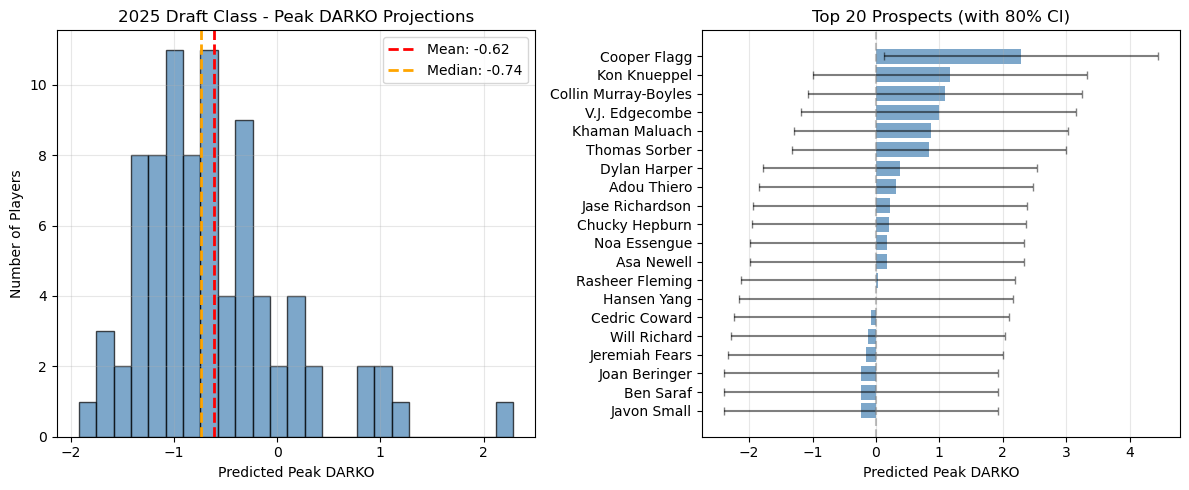

In [103]:
# Distribution of predictions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(rookies_2025['predicted_peak_darko'], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(rookies_2025['predicted_peak_darko'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {rookies_2025["predicted_peak_darko"].mean():.2f}')
plt.axvline(rookies_2025['predicted_peak_darko'].median(), color='orange', 
            linestyle='--', linewidth=2, label=f'Median: {rookies_2025["predicted_peak_darko"].median():.2f}')
plt.xlabel('Predicted Peak DARKO')
plt.ylabel('Number of Players')
plt.title('2025 Draft Class - Peak DARKO Projections')
plt.legend()
plt.grid(alpha=0.3)

# Top prospects with confidence intervals
plt.subplot(1, 2, 2)
top_20 = results.head(20).copy().reset_index(drop=True)
top_20_idx = range(len(top_20))

# Calculate error bar values (must be 1D arrays)
lower_error = top_20['predicted_peak_darko'].values - top_20['prediction_lower_80pct'].values
upper_error = top_20['prediction_upper_80pct'].values - top_20['predicted_peak_darko'].values

plt.barh(top_20_idx, top_20['predicted_peak_darko'], color='steelblue', alpha=0.7)
plt.errorbar(top_20['predicted_peak_darko'], top_20_idx, 
             xerr=[lower_error, upper_error],  # Now correctly shaped as [1D, 1D]
             fmt='none', ecolor='black', alpha=0.5, capsize=3)

# Set y-axis labels if you have player names
name_col = None
for col in ['player_name', 'name', 'Player', 'PLAYER']:
    if col in top_20.columns:
        name_col = col
        break

if name_col:
    plt.yticks(top_20_idx, top_20[name_col])
else:
    plt.yticks(top_20_idx, [f'Player {i+1}' for i in top_20_idx])

plt.xlabel('Predicted Peak DARKO')
plt.title('Top 20 Prospects (with 80% CI)')
plt.gca().invert_yaxis()
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

#### Save Results

In [105]:
# Save final model
final_model.save_model('peak_darko_final_model.txt')
print("\n✓ Model saved to 'peak_darko_final_model.txt'")

# Save predictions
rookies_2025.to_csv('2025_draft_predictions.csv', index=False)
print("✓ Predictions saved to '2025_draft_predictions.csv'")

# Save feature list (important for future predictions)
pd.DataFrame({'feature': strong_features}).to_csv('model_features.csv', index=False)
print("✓ Feature list saved to 'model_features.csv'")

# Save model performance metrics
metrics = {
    'model': 'LightGBM',
    'cv_mean_rmse': 1.6896,
    'cv_std_rmse': 0.0874,
    'test_rmse': 1.6757,
    'test_r2': 0.2357,
    'n_features': len(strong_features),
    'n_training_samples': len(X_final)
}
pd.DataFrame([metrics]).to_csv('model_performance.csv', index=False)
print("✓ Performance metrics saved to 'model_performance.csv'")

print("\n" + "="*70)
print("✓ COMPLETE! Your 2025 draft predictions are ready.")
print("="*70)


✓ Model saved to 'peak_darko_final_model.txt'
✓ Predictions saved to '2025_draft_predictions.csv'
✓ Feature list saved to 'model_features.csv'
✓ Performance metrics saved to 'model_performance.csv'

✓ COMPLETE! Your 2025 draft predictions are ready.
